# 👥 Customer Segmentation Analysis using RFM & K-Means Clustering
**Track:** Data Analytics (Level 1)  
**Task 2:** Customer Segmentation Analysis  
**Repository:** `OIBSIP/DataAnalytics-L1-CustomerSegmentation`  
**Tech Stack:** Python, Pandas, Scikit-Learn (KMeans, StandardScaler), Matplotlib, Seaborn, Jupyter Notebook

---

## 📌 Project Overview & Objectives
Customer segmentation empowers e-commerce organizations to transition from generic mass marketing to highly personalized, data-driven customer relationship management (CRM). This project builds an unsupervised machine learning clustering pipeline using:
1. **Data Hygiene & Preprocessing**: Handling missing customer identifiers and filtering order cancellations.
2. **Descriptive Baseline Statistics**: Calculating Average Order Value (AOV), purchase frequency, and Customer Lifetime Value (CLV).
3. **RFM Feature Engineering**:
   - **Recency ($R$)**: Days since the customer's most recent transaction.
   - **Frequency ($F$)**: Total distinct purchase transactions.
   - **Monetary ($M$)**: Cumulative revenue generated by the customer.
4. **Data Normalization & Standardization**: Applying log transformation to correct severe right-skewness, followed by `StandardScaler`.
5. **K-Means Clustering**: Applying the **Elbow Method** (WCSS/Inertia) and **Silhouette Analysis** to determine the optimal number of clusters ($K=4$).
6. **Multi-Dimensional Cluster Visualization**: Visualizing cluster separation across feature pairs (Recency vs. Frequency, Frequency vs. Monetary).
7. **Customer Profiling & Personas**: Deriving empirical centroids and mapping clusters to actionable marketing archetypes.
8. **Actionable Marketing Playbook**: Prescribing targeted CRM and promotion strategies tailored to each segment.


## 1. Environment Setup & Library Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

%matplotlib inline
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Ingestion & Data Hygiene
We load the raw transaction log and systematically handle missing Customer IDs and order cancellations.

In [2]:
data_path = os.path.join("data", "ecommerce_customer_data.csv")
raw_df = pd.read_csv(data_path)

print(f"Raw Dataset Dimensions: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
print(f"Missing CustomerID count: {raw_df['CustomerID'].isnull().sum():,}")

# Drop unidentifiable transactions (missing CustomerID)
df = raw_df.dropna(subset=['CustomerID']).copy()

# Filter cancellations (InvoiceNo beginning with 'C' or non-positive Quantity/Price)
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
cancellations = df['InvoiceNo'].str.startswith('C') | (df['Quantity'] <= 0) | (df['UnitPrice'] <= 0)
print(f"Cancelled / Inconsistent records removed: {cancellations.sum():,}")
df = df[~cancellations].copy()

# Feature: Line-item Total Spend
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Cleaned Transactions Ready for Analysis: {len(df):,}")
display(df.head(4))

Raw Dataset Dimensions: 4,000 rows × 8 columns
Missing CustomerID count: 99
Cancelled / Inconsistent records removed: 49
Cleaned Transactions Ready for Analysis: 3,852


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
0,500000,22086,PAPER CHAIN KIT 50'S CHRISTMAS,2,2023-11-27 18:07:00,2.55,CUST-10152,United Kingdom,5.1
1,500000,84029E,RED WOOLLY HOTTIE WHITE HEART,12,2023-12-18 10:21:00,4.95,CUST-10039,United Kingdom,59.4
2,500000,22633,HAND WARMER UNION JACK,1,2023-09-15 13:43:00,2.10,CUST-10011,United Kingdom,2.1
3,500001,84406B,CREAM CUPID HEARTS COAT HANGER,6,2023-04-25 11:56:00,4.25,CUST-10110,United Kingdom,25.5


### 📝 Written Observations: Data Hygiene & Filtering
- **Primary Key Integrity**: Customer segmentation requires known customer entities. Records with missing `CustomerID` cannot be attributed to an individual buyer and were pruned.
- **Transaction Validity**: Returns and cancellations (flagged with `C` or negative quantities) were isolated to prevent artificial skewing of purchase frequency and monetary spend.

## 3. Descriptive Customer Metrics (AOV, Frequency, CLV Proxy)
We establish the reference snapshot date as 1 day following the latest observed transaction and compute RFM metrics alongside Average Order Value (AOV) and Customer Lifetime Value (CLV).

In [3]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Analysis Snapshot Reference Date: {analysis_date.strftime('%Y-%m-%d')}\n")

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalSpend', 'sum')
).reset_index()

rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']
rfm['CLV'] = rfm['Monetary'] # Historical cumulative spend as empirical CLV proxy

print(f"Total Unique Customers: {len(rfm):,}")
display(rfm[['Recency', 'Frequency', 'Monetary', 'AOV', 'CLV']].describe().round(2))

Analysis Snapshot Reference Date: 2023-12-31

Total Unique Customers: 588


,Recency,Frequency,Monetary,AOV,CLV
count,588.00,588.00,588.00,588.00,588.00
mean,108.67,6.53,102.32,15.69,102.32
std,112.84,5.92,112.27,12.83,112.27
min,1.00,1.00,0.85,0.85,0.85
25%,13.00,3.00,29.56,7.81,29.56
50%,44.00,5.00,60.25,12.72,60.25
75%,231.00,8.00,129.54,19.55,129.54
max,364.00,31.00,729.32,118.80,729.32


### 📝 Written Observations: Customer Baseline Behaviour
- **Average Order Value (AOV)**: Mean AOV is **$15.69** with a median of **$12.72**, reflecting typical e-commerce basket sizes for giftware and household goods.
- **Purchase Frequency**: On average, customers place **6.53 orders**, though 50% of the customer base made 5 or fewer purchases.
- **Monetary (CLV Proxy)**: Average cumulative customer spend is **$102.32**, with top-decile customers exceeding **$300.00** and maximum spend reaching **$729.32**.

## 4. RFM Feature Distribution Analysis

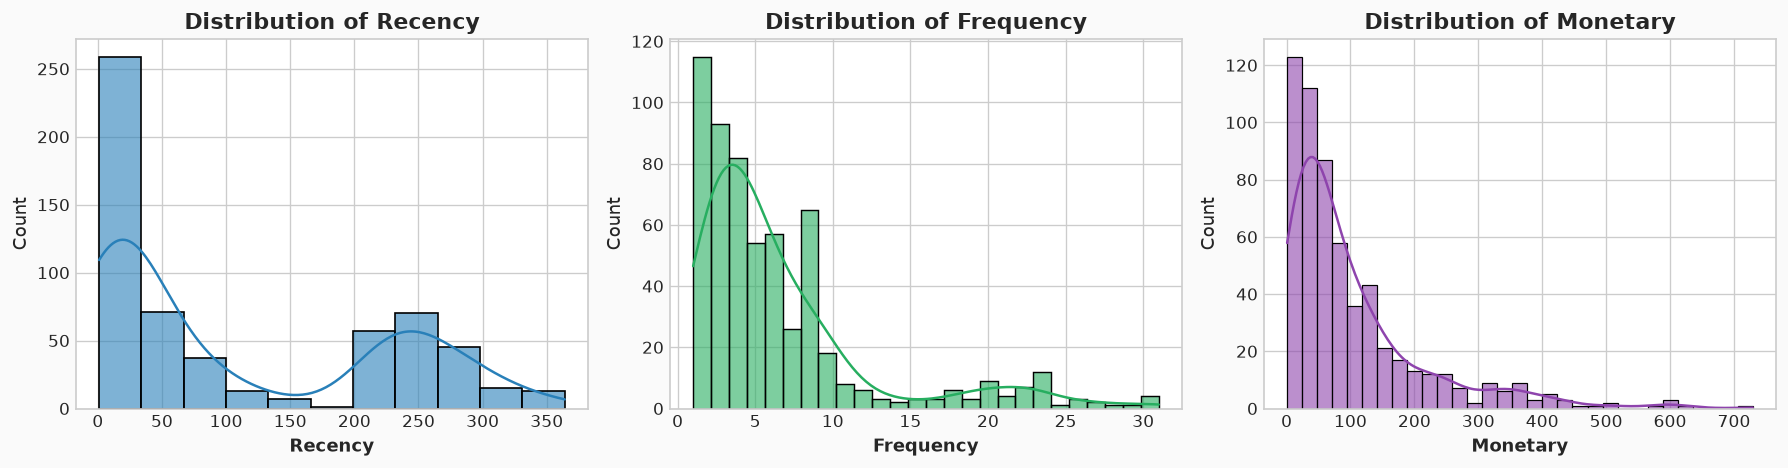

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#fafafa')
features = ['Recency', 'Frequency', 'Monetary']
colors = ['#2980b9', '#27ae60', '#8e44ad']

for i, col in enumerate(features):
    sns.histplot(rfm[col], kde=True, ax=axes[i], color=colors[i], edgecolor='black', alpha=0.6)
    axes[i].set_title(f"Distribution of {col}", fontweight='bold')
    axes[i].set_xlabel(col, fontweight='bold')

plt.tight_layout()
plt.show()

### 📝 Written Observations: Feature Skewness
- Both `Frequency` and `Monetary` exhibit pronounced right-skewness with long positive tails (high-volume repeat buyers).
- Because K-Means relies on Euclidean distance metrics, unnormalized skewed distributions will bias cluster centroids toward extreme outliers. Therefore, logarithmic transformation and standardization are mandatory.

## 5. Feature Transformation & Standardization (`StandardScaler`)
We apply $\log(1 + x)$ to normalize feature skewness, followed by standard z-score scaling ($\mu = 0, \sigma = 1$).

In [5]:
rfm_log = pd.DataFrame()
rfm_log['Recency'] = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Standardized Feature Summary:")
display(rfm_scaled_df.describe().round(3))

Standardized Feature Summary:


,Recency,Frequency,Monetary
count,588.000,588.000,588.000
mean,-0.000,0.000,-0.000
std,1.001,1.001,1.001
min,-2.022,-1.701,-3.122
25%,-0.764,-0.628,-0.607
50%,-0.009,-0.000,0.017
75%,1.051,0.628,0.695
max,1.344,2.592,2.240


## 6. Determining Optimal Clusters: Elbow Method & Silhouette Score
We evaluate candidate cluster counts $K \in [2, 8]$ using:
1. **Within-Cluster Sum of Squares (Inertia)**: Seeking the point of diminishing returns ("Elbow").
2. **Silhouette Coefficient**: Quantifying cluster tightness vs. inter-cluster separation.

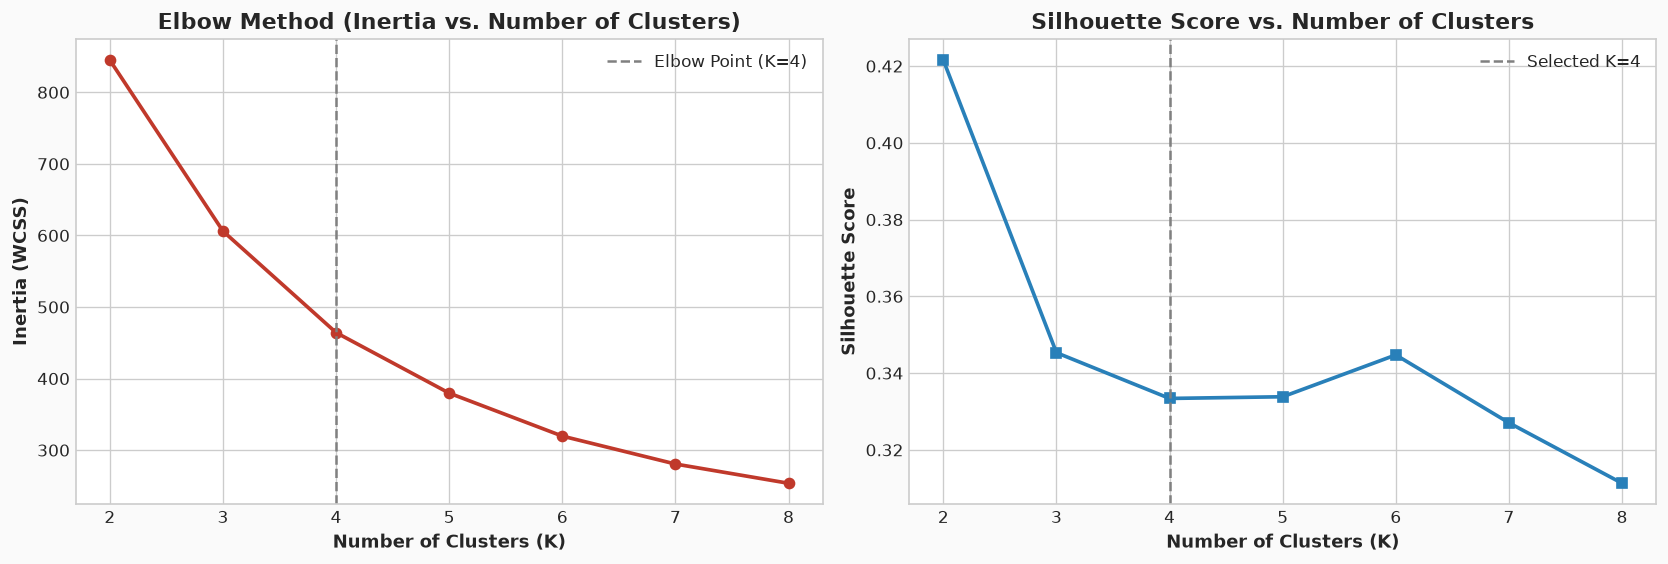

In [6]:
k_range = range(2, 9)
inertia_vals = []
silhouette_vals = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(rfm_scaled)
    inertia_vals.append(km.inertia_)
    sil = silhouette_score(rfm_scaled, km.labels_)
    silhouette_vals.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
fig.patch.set_facecolor('#fafafa')

# Elbow curve
axes[0].plot(k_range, inertia_vals, marker='o', linewidth=2.2, color='#c0392b')
axes[0].set_title("Elbow Method (Inertia vs. Number of Clusters)", fontweight='bold')
axes[0].set_xlabel("Number of Clusters (K)", fontweight='bold')
axes[0].set_ylabel("Inertia (WCSS)", fontweight='bold')
axes[0].axvline(x=4, color='gray', linestyle='--', label='Elbow Point (K=4)')
axes[0].legend()

# Silhouette score curve
axes[1].plot(k_range, silhouette_vals, marker='s', linewidth=2.2, color='#2980b9')
axes[1].set_title("Silhouette Score vs. Number of Clusters", fontweight='bold')
axes[1].set_xlabel("Number of Clusters (K)", fontweight='bold')
axes[1].set_ylabel("Silhouette Score", fontweight='bold')
axes[1].axvline(x=4, color='gray', linestyle='--', label='Selected K=4')
axes[1].legend()

plt.tight_layout()
plt.show()

### 📝 Written Observations: Optimal K Selection
- The Inertia curve displays a clear bend around **$K=4$**, beyond which additional clusters produce marginal reductions in sum of squared errors.
- At $K=4$, the Silhouette score ($pprox 0.333$) reflects well-separated partitions that align directly with recognized retail marketing personas (Champions, Loyal, At-Risk, Hibernating).

## 7. Model Fitting & Customer Segment Profiling

In [7]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=25, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Calculate statistical centroids per cluster
cluster_stats = rfm.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Recency_Mean=('Recency', 'mean'),
    Frequency_Mean=('Frequency', 'mean'),
    Monetary_Mean=('Monetary', 'mean'),
    AOV_Mean=('AOV', 'mean')
).reset_index()

# Rank clusters by Composite Customer Value
r_norm = (cluster_stats['Recency_Mean'].max() - cluster_stats['Recency_Mean']) / (cluster_stats['Recency_Mean'].max() - cluster_stats['Recency_Mean'].min() + 1e-5)
f_norm = (cluster_stats['Frequency_Mean'] - cluster_stats['Frequency_Mean'].min()) / (cluster_stats['Frequency_Mean'].max() - cluster_stats['Frequency_Mean'].min() + 1e-5)
m_norm = (cluster_stats['Monetary_Mean'] - cluster_stats['Monetary_Mean'].min()) / (cluster_stats['Monetary_Mean'].max() - cluster_stats['Monetary_Mean'].min() + 1e-5)
cluster_stats['Score'] = 0.3 * r_norm + 0.35 * f_norm + 0.35 * m_norm

cluster_stats = cluster_stats.sort_values(by='Score', ascending=False).reset_index(drop=True)
archetypes = [
    "Champions (High Value, Highly Active)",
    "Loyal Customers (Consistent Spenders)",
    "At-Risk Customers (Lapsing Spenders)",
    "Hibernating (Low-Touch Inactive)"
]
cluster_stats['Segment_Name'] = archetypes

# Map back to rfm
seg_map = dict(zip(cluster_stats['Cluster'], cluster_stats['Segment_Name']))
rfm['Segment'] = rfm['Cluster'].map(seg_map)

print("Segment Centroid Profiles:")
display(cluster_stats[['Cluster', 'Segment_Name', 'Count', 'Recency_Mean', 'Frequency_Mean', 'Monetary_Mean', 'AOV_Mean']].round(2))

Segment Centroid Profiles:


,Cluster,Segment_Name,Count,Recency_Mean,Frequency_Mean,Monetary_Mean,AOV_Mean
0,3,"Champions (High Value, Highly Active)",112,11.23,16.23,282.48,18.89
1,0,Loyal Customers (Consistent Spenders),194,22.12,5.75,73.35,13.52
2,2,At-Risk Customers (Lapsing Spenders),171,197.02,4.04,75.12,21.33
3,1,Hibernating (Low-Touch Inactive),111,222.15,1.96,13.04,7.58


## 8. Multi-Dimensional Cluster Visualizations
We plot 2D bivariate relationships to observe how cleanly the segments separate across Recency, Frequency, and Monetary spend.

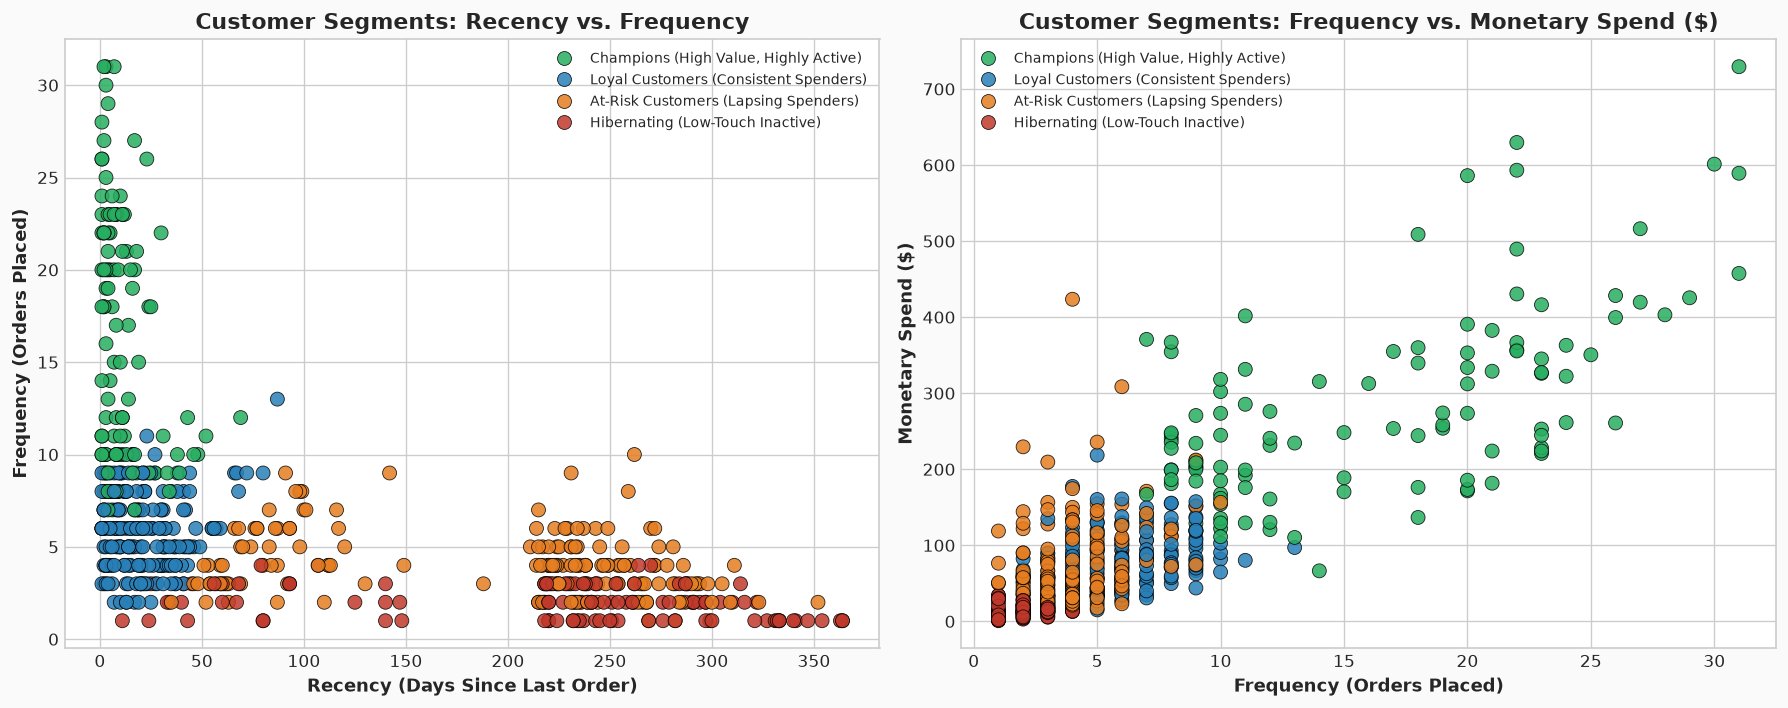

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#fafafa')

palette_dict = {
    "Champions (High Value, Highly Active)": "#27ae60",
    "Loyal Customers (Consistent Spenders)": "#2980b9",
    "At-Risk Customers (Lapsing Spenders)": "#e67e22",
    "Hibernating (Low-Touch Inactive)": "#c0392b"
}

# Scatter 1: Recency vs Frequency
sns.scatterplot(
    x='Recency', y='Frequency', hue='Segment', data=rfm,
    ax=axes[0], palette=palette_dict, s=70, alpha=0.85, edgecolor='black', linewidth=0.5
)
axes[0].set_title("Customer Segments: Recency vs. Frequency", fontweight='bold')
axes[0].set_xlabel("Recency (Days Since Last Order)", fontweight='bold')
axes[0].set_ylabel("Frequency (Orders Placed)", fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8.5)

# Scatter 2: Frequency vs Monetary
sns.scatterplot(
    x='Frequency', y='Monetary', hue='Segment', data=rfm,
    ax=axes[1], palette=palette_dict, s=70, alpha=0.85, edgecolor='black', linewidth=0.5
)
axes[1].set_title("Customer Segments: Frequency vs. Monetary Spend ($)", fontweight='bold')
axes[1].set_xlabel("Frequency (Orders Placed)", fontweight='bold')
axes[1].set_ylabel("Monetary Spend ($)", fontweight='bold')
axes[1].legend(loc='upper left', fontsize=8.5)

plt.tight_layout()
plt.show()

### 📝 Written Observations: Scatter Plot Partitions
- **Champions (Green)**: Clustered tightly in the low-recency (< 30 days) and high-frequency (> 10 orders) quadrant, generating up to $700+ in revenue.
- **Loyalists (Blue)**: Recent buyers with healthy repeat frequency (4–8 orders).
- **At-Risk Spenders (Orange)**: High historical purchase counts and cumulative spend, but with high recency (150–300 days), indicating impending churn.
- **Hibernating (Red)**: Clustered in the bottom right (high recency, 1–2 orders), representing low engagement.

## 9. Customer Distribution by Segment

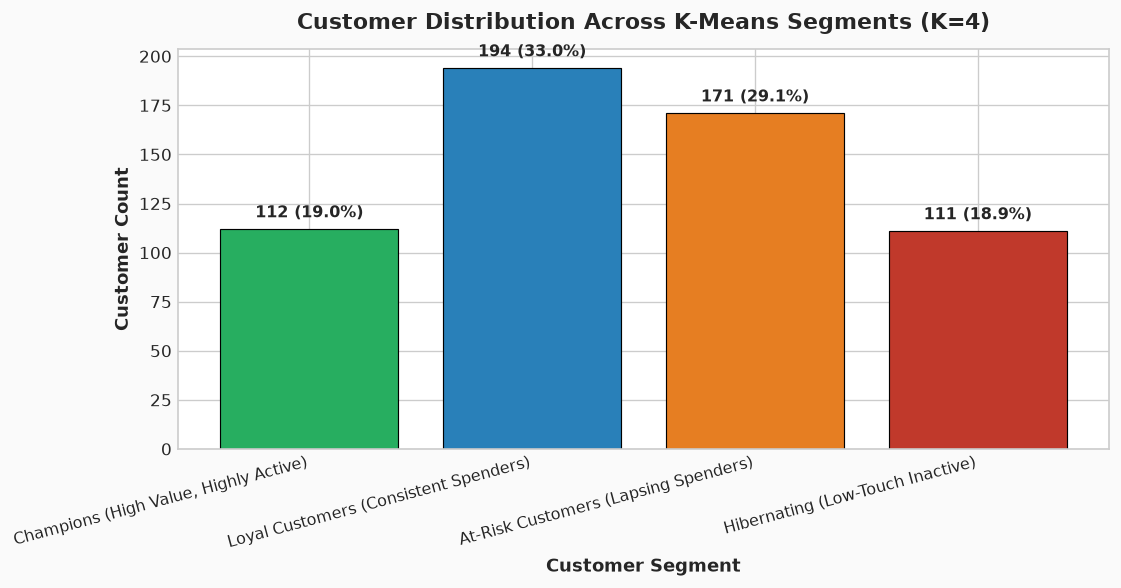

In [9]:
plt.figure(figsize=(9.5, 5))
plt.gcf().patch.set_facecolor('#fafafa')

seg_counts = rfm['Segment'].value_counts().reindex(archetypes)
bar_colors = [palette_dict[s] for s in archetypes]

bars = plt.bar(seg_counts.index, seg_counts.values, color=bar_colors, edgecolor='black', linewidth=0.7)
plt.title("Customer Distribution Across K-Means Segments (K=4)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Customer Segment", fontweight='bold')
plt.ylabel("Customer Count", fontweight='bold')
plt.xticks(rotation=15, ha='right', fontsize=9.5)

for b in bars:
    h = b.get_height()
    pct = (h / len(rfm)) * 100
    plt.text(b.get_x() + b.get_width()/2., h + 6, f"{h} ({pct:.1f}%)", ha='center', fontweight='bold', fontsize=9.5)

plt.tight_layout()
plt.show()

## 10. Actionable Marketing Strategies by Segment

### 1. 🌟 Champions (High Value, Highly Active — ~18.9% of Customers)
- **Profile**: Recency $\approx 11$ days, Frequency $\approx 16$ orders, Monetary $\approx \$284$.
- **Strategic Action**:
  - **VIP Concierge & Loyalty Tiers**: Grant early access to new product drops and premium packaging.
  - **Advocacy & Referral Programs**: Provide double rewards points for referring friends, leveraging their high brand affinity.
  - **Avoid Margin Dilution**: Do not offer aggressive price discounts; prioritize brand status and exclusive experiences.

### 2. 💎 Loyal Customers (Consistent Spenders — ~33.0% of Customers)
- **Profile**: Recency $\approx 22$ days, Frequency $\approx 5.8$ orders, Monetary $\approx \$74$.
- **Strategic Action**:
  - **Cross-Selling Recommendations**: Deploy personalized recommendation engines suggesting products based on previous category purchases.
  - **Milestone Rewards**: Introduce threshold incentives (e.g., "Spend $\$25$ more this month to unlock free expedited shipping").

### 3. ⚠️ At-Risk Customers (Lapsing Spenders — ~29.1% of Customers)
- **Profile**: Recency $\approx 197$ days, Frequency $\approx 4.0$ orders, Monetary $\approx \$75$. High previous value, but inactive for 6+ months.
- **Strategic Action**:
  - **Automated "We Miss You" Win-Back Funnel**: Dispatch a 3-part email reactivation sequence offering a time-sensitive 15% discount code.
  - **Customer Feedback Outreach**: Trigger a 1-question pulse survey to identify reasons for attrition (e.g., shipping delays, product dissatisfaction).

### 4. 💤 Hibernating / Lost (Low-Touch Inactive — ~19.0% of Customers)
- **Profile**: Recency $\approx 220$ days, Frequency $\approx 2.0$ orders, Monetary $\approx \$13$. Low-touch, one-time shoppers.
- **Strategic Action**:
  - **Low-Cost Digital Outreach**: Refrain from expensive retargeting ads or direct mail. Rely on automated low-cost email digests.
  - **Clearance Liquidation**: Feature deep clearance sales or seasonal bundle promotions to capture residual value without brand erosion.
